# **Classification of Car Evaluation Dataset using SVM with Hyperparameter tuning and Cross-validation**
## AI 221 Assignment 05

Submitted by: **Pangilinan, Reignel Bernice** 2018-01460 \\


Dataset reference: \\
Bohanec, M. (1988). Car Evaluation [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5JP48.

\\

Code is based on Dr. K. Pilario's work in https://github.com/kspilario/AI221/tree/main/Kernel_Methods and https://github.com/kspilario/AI221/tree/main/Cross-validation

## **Preliminaries**

**Objective**: \\
To perform multi-class classification of the car evaluation dataset using SVM with hyperparameter tuning and cross-validation and compare the results of two search strategies: grid search and randomized search.

In [ ]:
!pip install ucimlrepo    # Run first to install UCI ML repo package

In [ ]:
import numpy as np    # Import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OutputCodeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
import time

from ucimlrepo import fetch_ucirepo   # Dataset is from UCI ML repository, packaged for easier import to Python

### Fetch dataset
car_evaluation = fetch_ucirepo(id = 19)
print("Car evaluation dataset variables:")
print(car_evaluation.variables)  # Display variables

X_raw = car_evaluation.data.features  # Features dataframe
y_raw = car_evaluation.data.targets # Labels dataframe

car_data_raw = pd.concat((X_raw, y_raw), axis = 1)  # Combine labels and features into one dataframe
print("\nDataset before encoding:")
display(car_data_raw.head()) # Show the first few rows of the raw dataset, before encoding

### Encode features and labels to turn categorical data --> integers
encoder = LabelEncoder()
for column in X_raw.columns:  # Encode each entry per column containing the features
  X_raw.loc[:, column] = encoder.fit_transform(X_raw.loc[:, column])

X = pd.DataFrame(X_raw) # Assign encoded dataframe to X
y = pd.DataFrame(encoder.fit_transform(y_raw))  # Assign labels column to y

car_data = pd.concat((X, y), axis = 1)  # Combine labels and features into one dataframe
print("\nDataset after encoding:")
display(car_data.head()) # Show the first few rows of the dataset, after encoding

Car evaluation dataset variables:
       name     role         type demographic  \
0    buying  Feature  Categorical        None   
1     maint  Feature  Categorical        None   
2     doors  Feature  Categorical        None   
3   persons  Feature  Categorical        None   
4  lug_boot  Feature  Categorical        None   
5    safety  Feature  Categorical        None   
6     class   Target  Categorical        None   

                                         description units missing_values  
0                                       buying price  None             no  
1                           price of the maintenance  None             no  
2                                    number of doors  None             no  
3              capacity in terms of persons to carry  None             no  
4                           the size of luggage boot  None             no  
5                        estimated safety of the car  None             no  
6  evaulation level (unacceptable, accept

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc



Dataset after encoding:


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,buying,maint,doors,persons,lug_boot,safety,0
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


There are 4 classes in the dataset namely: *Acceptable*, *Unacceptable*, *Good*, and *Very Good*. These categorical labels have to be encoded first into numerical values (integers) before using the SVM model on them. *LabelEncoder()* is used for that purpose.

## **SVM with Hyperparameter tuning and Cross-validation using GridSearchCV**

Training set has 1209 instances and 6 features.
Testing set has 519 instances and 6 features.

Best parameters: {'C': 1000, 'gamma': 0.1, 'kernel': 'rbf'}

Cross-validation score: 0.9851136792291074

Accuracy: 0.9865125240847784
Computing and training time using GridSearchCV: 70.6784 s
              precision    recall  f1-score   support

  Acceptable       0.97      0.97      0.97       115
        Good       1.00      1.00      1.00        21
Unacceptable       0.99      0.99      0.99       363
   Very Good       1.00      1.00      1.00        20

    accuracy                           0.99       519
   macro avg       0.99      0.99      0.99       519
weighted avg       0.99      0.99      0.99       519



/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


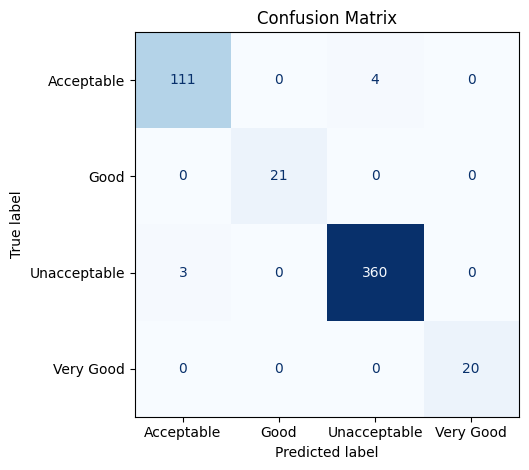

Misclassified predictions:
True: Acceptable 			 Predicted: Unacceptable
True: Unacceptable 			 Predicted: Acceptable
True: Acceptable 			 Predicted: Unacceptable
True: Unacceptable 			 Predicted: Acceptable
True: Unacceptable 			 Predicted: Acceptable
True: Acceptable 			 Predicted: Unacceptable
True: Acceptable 			 Predicted: Unacceptable
Total number of misclassified labels: 7


In [ ]:
from sklearn.model_selection import GridSearchCV

### Split the dataset into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 42)  # Split the data into training and testing sets
print(f"Training set has {X_train.shape[0]} instances and {X_train.shape[1]} features.")
print(f"Testing set has {X_test.shape[0]} instances and {X_test.shape[1]} features.")

### Perform GridSearch to find the best parameters for the SVM model
params = {"C": [0.1, 1, 10, 100, 1000],
          "gamma": [1, 0.1, 0.01, 0.001, 0.0001],
          "kernel": ["rbf", "linear"]}  # Dictionary of the possible values of the parameters

start = time.time() # Record computing time for GridSearchCV and training time using the best parameters

grid_search = GridSearchCV(SVC(), params, cv = 5, n_jobs = -1)  # Perform the grid search with 5 folds
grid_search.fit(X_train, y_train.values.ravel())

best_params = grid_search.best_params_  # Determine the best parameters from the GridSearch
print(f"\nBest parameters: {best_params}")  # Display the best parameters

cross_val_score = grid_search.best_score_  # Determine the cross-validation score
print(f"\nCross-validation score: {cross_val_score}")  # Display the cross-validation score

svm_best = make_pipeline(StandardScaler(), SVC(**best_params)) # Use best parameters to create the SVM model
svm_best.fit(X_train, y_train.values.ravel()) # Train the model using the best parameters

end = time.time()

### Use the model with the best parameters on unseen data
y_pred = svm_best.predict(X_test)  # Test SVM model on unseen data
print(f"\nAccuracy: {svm_best.score(X_test, y_test)}")  # Display the accuracy
print(f"Computing and training time using GridSearchCV: {np.round(end - start, 4)} s") # Display time

### Plot the confusion matrix
y_test = list(encoder.inverse_transform(y_test))  # Decode the encoded labels
y_pred = list(encoder.inverse_transform(y_pred))

for i in range(len(y_test)):  # Edit the labels to be more "human-friendly"
  if y_test[i] == "acc":
    y_test[i] = "Acceptable"
  elif y_test[i] == "unacc":
    y_test[i] = "Unacceptable"
  elif y_test[i] == "good":
    y_test[i] = "Good"
  elif y_test[i] == "vgood":
    y_test[i] = "Very Good"

for i in range(len(y_pred)):  # Edit the labels to be more "human-friendly"
  if y_pred[i] == "acc":
    y_pred[i] = "Acceptable"
  elif y_pred[i] == "unacc":
    y_pred[i] = "Unacceptable"
  elif y_pred[i] == "good":
    y_pred[i] = "Good"
  elif y_pred[i] == "vgood":
    y_pred[i] = "Very Good"

print(classification_report(y_test, y_pred)) # Display classification report

cm = confusion_matrix(y_test, y_pred) # Display the confusion matrix
ConfusionMatrixDisplay(cm, display_labels = list(np.unique(y_test))).plot(cmap = plt.cm.Blues, colorbar = False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Display misclassified predictions
print("Misclassified predictions:")
misclassified = 0
for i in range(len(y_test)):  # Print the true and predicted labels of misclassified
  if y_test[i] != y_pred[i]:
    print(f"True: {y_test[i]} \t\t\t Predicted: {y_pred[i]}")
    misclassified += 1  # Count number of misclassified labels

print(f"Total number of misclassified labels: {misclassified}")  # Print number of misclassified labels

## **SVM with Hyperparameter tuning and Cross-validation using RandomizedSearchCV**

Training set has 1209 instances and 6 features.
Testing set has 519 instances and 6 features.


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Best parameters: {'kernel': 'rbf', 'gamma': 1, 'C': 1000}

Cross-validation score: 0.9578066595795753

Accuracy: 0.9730250481695568
Computing and training time using RandomizedSearchCV: 12.7433 s
              precision    recall  f1-score   support

  Acceptable       0.94      0.94      0.94       115
        Good       0.95      0.95      0.95        21
Unacceptable       0.98      0.99      0.98       363
   Very Good       1.00      0.95      0.97        20

    accuracy                           0.97       519
   macro avg       0.97      0.96      0.96       519
weighted avg       0.97      0.97      0.97       519



/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


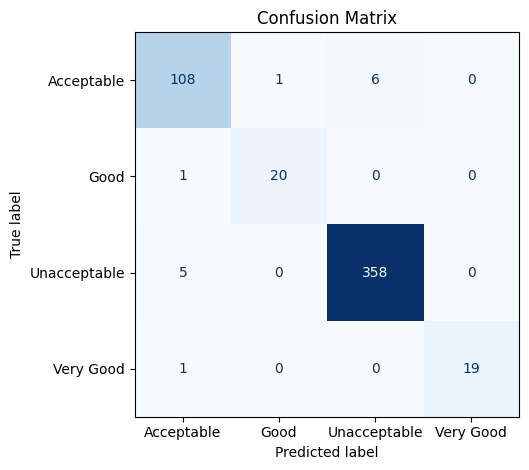

Misclassified predictions:
True: Acceptable 			 Predicted: Unacceptable
True: Acceptable 			 Predicted: Unacceptable
True: Acceptable 			 Predicted: Unacceptable
True: Acceptable 			 Predicted: Unacceptable
True: Good 			 Predicted: Acceptable
True: Unacceptable 			 Predicted: Acceptable
True: Acceptable 			 Predicted: Unacceptable
True: Unacceptable 			 Predicted: Acceptable
True: Acceptable 			 Predicted: Unacceptable
True: Unacceptable 			 Predicted: Acceptable
True: Unacceptable 			 Predicted: Acceptable
True: Very Good 			 Predicted: Acceptable
True: Unacceptable 			 Predicted: Acceptable
True: Acceptable 			 Predicted: Good
Total number of misclassified labels: 14


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

### Split the dataset into training and testing set
X = pd.DataFrame(X_raw) # Assign encoded dataframe to X
y = pd.DataFrame(encoder.fit_transform(y_raw))  # Assign labels column to y

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 42)  # Split the data into training and testing sets
print(f"Training set has {X_train1.shape[0]} instances and {X_train1.shape[1]} features.")
print(f"Testing set has {X_test1.shape[0]} instances and {X_test1.shape[1]} features.")

### Perform GridSearch to find the best parameters for the SVM model
params = {"C": [0.1, 1, 10, 100, 1000],
          "gamma": [1, 0.1, 0.01, 0.001, 0.0001],
          "kernel": ["rbf", "linear"]}  # Dictionary of the possible values of the parameters

start = time.time() # Record computing time for GridSearchCV and training time using the best parameters

random_search = RandomizedSearchCV(SVC(), params, cv = 5, n_jobs = -1)  # Perform the randomized search with 5 folds
random_search.fit(X_train1, y_train1.values.ravel())

best_params = random_search.best_params_  # Determine the best parameters from the GridSearch
print(f"\nBest parameters: {best_params}")  # Display the best parameters

cross_val_score_rand = random_search.best_score_  # Determine the cross-validation score
print(f"\nCross-validation score: {cross_val_score_rand}")  # Display the cross-validation score

svm_best_rand = make_pipeline(StandardScaler(), SVC(**best_params)) # Use best parameters to create the SVM model
svm_best_rand.fit(X_train1, y_train1.values.ravel()) # Train the model using the best parameters

end = time.time()

### Use the model with the best parameters on unseen data
y_pred1 = svm_best_rand.predict(X_test1)  # Test SVM model on unseen data
print(f"\nAccuracy: {svm_best_rand.score(X_test1, y_test1)}")  # Display the accuracy
print(f"Computing and training time using RandomizedSearchCV: {np.round(end - start, 4)} s") # Display time

### Plot the confusion matrix
y_test1 = list(encoder.inverse_transform(y_test1))  # Decode the encoded labels
y_pred1 = list(encoder.inverse_transform(y_pred1))

for i in range(len(y_test1)):  # Edit the labels to be more "human-friendly"
  if y_test1[i] == "acc":
    y_test1[i] = "Acceptable"
  elif y_test1[i] == "unacc":
    y_test1[i] = "Unacceptable"
  elif y_test1[i] == "good":
    y_test1[i] = "Good"
  elif y_test1[i] == "vgood":
    y_test1[i] = "Very Good"

for i in range(len(y_pred1)):  # Edit the labels to be more "human-friendly"
  if y_pred1[i] == "acc":
    y_pred1[i] = "Acceptable"
  elif y_pred1[i] == "unacc":
    y_pred1[i] = "Unacceptable"
  elif y_pred1[i] == "good":
    y_pred1[i] = "Good"
  elif y_pred1[i] == "vgood":
    y_pred1[i] = "Very Good"

print(classification_report(y_test1, y_pred1)) # Display classification report

cm = confusion_matrix(y_test1, y_pred1) # Display the confusion matrix
ConfusionMatrixDisplay(cm, display_labels = list(np.unique(y_test1))).plot(cmap = plt.cm.Blues, colorbar = False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Display misclassified predictions
print("Misclassified predictions:")
misclassified = 0
for i in range(len(y_test1)):  # Print the true and predicted labels of misclassified
  if y_test1[i] != y_pred1[i]:
    print(f"True: {y_test1[i]} \t\t\t Predicted: {y_pred1[i]}")
    misclassified += 1  # Count number of misclassified labels

print(f"Total number of misclassified labels: {misclassified}")  # Print number of misclassified labels

## **Conclusions**

In general, the following observations may be made according to the results of the experiment:


*   The best parameters for GridSearchCV are: *C* : 1000, *gamma* : 0.1, *kernel* : "rbf" while RandomizedSearchCV best parameters are: *C* : 10, *gamma* : 0.1, *kernel* : "rbf". The difference is only in the hyperparameter C.

*   GridSearchCV cross-validation score > RandomizedSearchCV cross-validation score.

*   GridSearchCV accuracy > RandomizedSearchCV accuracy.


*   GridSearchCV computing and training time > RandomizedSearchCV computing and training time.

*   Number of misclassified labels using GridSearchCV < Number of misclassified labels using RandomizedSearchCV

\\

Thus, in finding the best model, if the accuracy and high classification scores are of more importance rather than the computation time, it is best to use GridSearchCV in hyperparameter tuning. The converse is true for RandomizedSearchCV; if faster computation time is preferred with a good enough accuracy score, RandomizedSearchCV may be used. Note, however, that this is only true for the dataset used and experiment done in this report and (I think) the best strategy still depends on the dataset with which we want to perform multi-class classification.

